# Strategy Design


In [31]:
import numpy as np

from hftbacktest import (
    BacktestAsset,
    HashMapMarketDepthBacktest,
    ROIVectorMarketDepthBacktest,
    Recorder
)
from hftbacktest.stats import LinearAssetRecord

Save the backtest module into `lib/pmm.py`


In [32]:
import lib.pmm_pure as pmm_pure

In [33]:
# %%time
xrpusdt_20250717 = np.load('data/output/xrpusdt_20250630.npz')['data']
# xrpusdt_20250717 = np.load('data/slices/xrpusdt_20250717_2h_77562432/split_003_2h.npz')['data']


roi_lb = 1    # ROI下界100tick，订单簿深度计算的价格下限
roi_ub = 5    # ROI上界200tick，订单簿深度计算的价格上限

asset = (
    BacktestAsset()
    .data([
        xrpusdt_20250717
    ])
    .linear_asset(1)
    .no_partial_fill_exchange()
    .constant_latency(10_000_000, 10_000_000)
    .tick_size(0.0001)  # 最小 Price precision (0.01 USDT)
    .lot_size(0.1)  # 最小 Trading amount (0.001 ETH)
    .trading_value_fee_model(-0.00003, 0.0007)  # Binance
    .power_prob_queue_model3(1.0)
    .risk_adverse_queue_model()
)


# hbt = ROIVectorMarketDepthBacktest([asset])
hbt = HashMapMarketDepthBacktest([asset])
recorder = Recorder(1, 5_000_000)

order_qty_dollar = 10


_ = pmm_pure.pure_pmm(
    hbt,
    recorder.recorder,
    half_spread=20,
    skew=1,
    interval=1_000_000_000,
    order_qty_dollar=order_qty_dollar,
    max_position_dollar=1000,
    grid_num=10,
    grid_interval=20
)

_ = hbt.close()

recorder.to_npz('stats/pmm_xrpusdt1.npz')

In [34]:
data = np.load('stats/pmm_xrpusdt1.npz')['0']
stats = (
    LinearAssetRecord(data)
    .resample('1s')
    .stats()
)
stats.summary()

start,end,SR,Sortino,Return,MaxDrawdown,DailyNumberOfTrades,DailyTradingValue,ReturnOverMDD,ReturnOverTrade,MaxPositionValue
datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-06-30 00:00:00,2025-06-30 23:59:59,130.304495,282.071501,77.027389,2.966688,2300.026621,22956.580101,25.964102,0.003355,525.947625


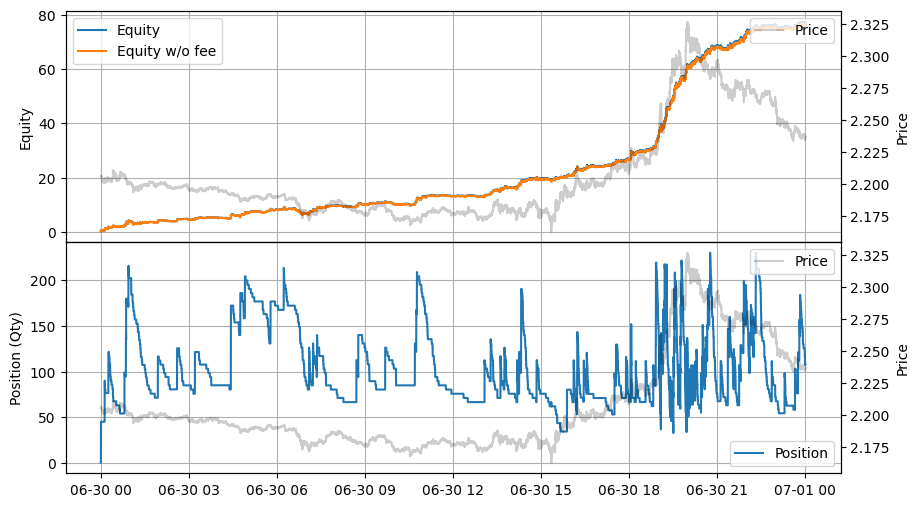

In [35]:
stats.plot()